# 1. Preparando o Ambiente de Análise 🛠️

Nesta etapa inicial, **eu configurei** as ferramentas que usarei para inspecionar os dados. Importei bibliotecas essenciais de visualização (`seaborn`, `matplotlib`) e defini os caminhos relativos para garantir que o notebook encontre o arquivo CSV gerado pelo meu pipeline de engenharia de dados.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminhos (ajustando para rodar de dentro da pasta notebooks)
PROCESSED_PATH = '../data/processed/dataset_espelhos.csv'
RAW_PATH = '../data/raw/'
    
print("Bibliotecas importadas e caminhos definidos.")

Bibliotecas importadas e caminhos definidos.


# 2. Carregamento do Dataset Processado 📂

Aqui, **carreguei o resultado final** da etapa de ingestão de dados. Meu objetivo foi confirmar se o script `run_ingestion.py` gerou o arquivo corretamente e visualizar as primeiras linhas para ter uma noção imediata da estrutura tabular que consegui extrair dos PDFs.

In [53]:
# Carregar o dataset gerado pelo pipeline
try:
    df = pd.read_csv(PROCESSED_PATH)
    print(f"✅ Dataset carregado com sucesso! Dimensões: {df.shape}")
except FileNotFoundError:
    print("❌ Arquivo não encontrado. Verifique se rodou o 'run_ingestion.py'.")

# Mostrar as primeiras linhas
df.head(14) # Mostra todos já que são poucos

✅ Dataset carregado com sucesso! Dimensões: (14, 12)


,Nome_Arquivo,Idade,Diagnostico_Texto_Livre,Sexo,Necessidade_Dialise,Instabilidade_Hemodinamica,Hemorragia_Ativa,Suspeita_Infecciosa,Oncologia_Fora_Perfil,Sinais_Vitais_O2_Suporte,Sinais_Gastro_Hepato,CID_10
0,CML.pdf,72,"PRINCIPAIS SINAIS E SINTOMAS: PACIENTE, 72 ANO...",FEMININO,1,1,0,0,0,1,1,R18
1,CWSS.pdf,42,PRINCIPAIS SINAIS E SINTOMAS: # HD: - ICTÉRICI...,MASCULINO,1,0,1,0,0,0,1,C221
2,DJA.pdf,46,PRINCIPAIS SINAIS E SINTOMAS: PACIENTE QUEIXA-...,MASCULINO,0,0,0,0,0,0,1,K51
3,EAS.pdf,49,PRINCIPAIS SINAIS E SINTOMAS: PACIENTE COM HD ...,MASCULINO,1,0,1,0,0,1,1,I85
4,ECL.pdf,43,PRINCIPAIS SINAIS E SINTOMAS: ADMISSAO 23/10: ...,FEMININO,0,0,1,0,0,0,1,K92
5,EES.pdf,38,PRINCIPAIS SINAIS E SINTOMAS: RCU EM DEZEMBRO ...,MASCULINO,1,0,1,1,0,1,1,K519
6,EFC.pdf,29,PRINCIPAIS SINAIS E SINTOMAS: # EVOLUÇAO LEITO...,MASCULINO,0,1,1,0,0,1,1,R18
7,EJA.pdf,43,PRINCIPAIS SINAIS E SINTOMAS: PACIENTE REFERE ...,MASCULINO,1,0,1,0,0,1,1,K508
8,FAA.pdf,48,PRINCIPAIS SINAIS E SINTOMAS: EMERGENCIA CLINI...,MASCULINO,1,1,1,0,0,0,1,K57
9,JDAC.pdf,36,PRINCIPAIS SINAIS E SINTOMAS: PACIENTE MASCULI...,MASCULINO,0,0,0,0,0,1,1,K859


# 3. Raio-X da Qualidade dos Dados (Valores Nulos) 🔍

Precisava entender a integridade dos dados extraídos. **Utilizei um mapa de calor (heatmap)** para visualizar onde estão os "buracos" (dados nulos).

* **Minha intenção:** Descobrir se falhas na extração de campos específicos (como Idade ou Texto Diagnóstico) são isoladas ou sistêmicas em todo o dataset.

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Nome_Arquivo                14 non-null     object
 1   Idade                       14 non-null     int64 
 2   Diagnostico_Texto_Livre     14 non-null     object
 3   Sexo                        14 non-null     object
 4   Necessidade_Dialise         14 non-null     int64 
 5   Instabilidade_Hemodinamica  14 non-null     int64 
 6   Hemorragia_Ativa            14 non-null     int64 
 7   Suspeita_Infecciosa         14 non-null     int64 
 8   Oncologia_Fora_Perfil       14 non-null     int64 
 9   Sinais_Vitais_O2_Suporte    14 non-null     int64 
 10  Sinais_Gastro_Hepato        14 non-null     int64 
 11  CID_10                      14 non-null     object
dtypes: int64(8), object(4)
memory usage: 1.4+ KB

--- Contagem de Valores Nulos

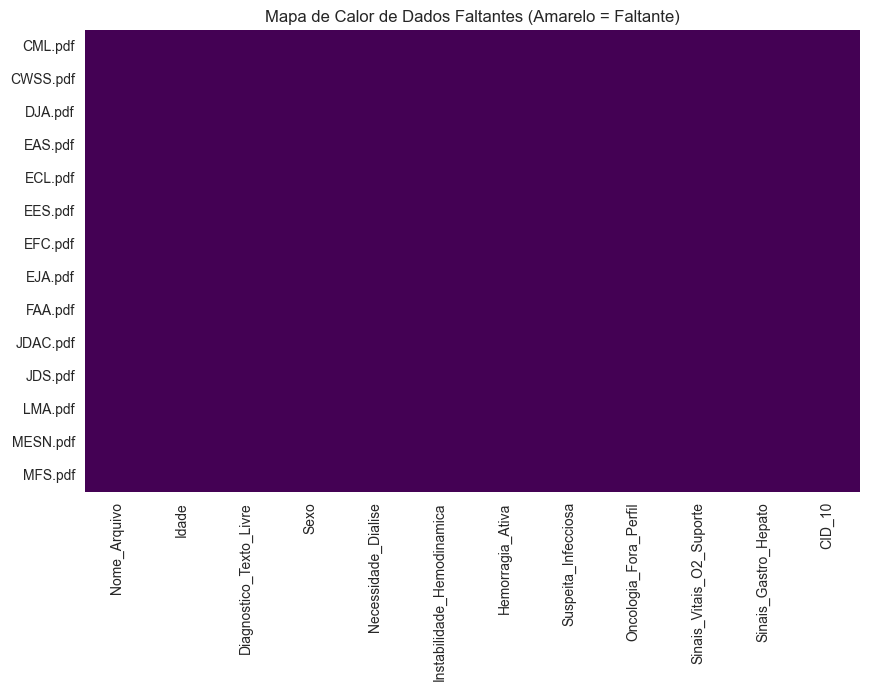

In [54]:
# Verificar tipos de dados e valores nulos
print("--- Informações do DataFrame ---")
df.info()

print("\n--- Contagem de Valores Nulos ---")
print(df.isnull().sum())

# Visualizar onde estão os nulos (Mapa de Calor)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=df['Nome_Arquivo'])
plt.title("Mapa de Calor de Dados Faltantes (Amarelo = Faltante)")
plt.show()

# 4. Investigação de Erros de Encoding (Artefatos de PDF) 🛑

Durante o desenvolvimento, **notei que alguns PDFs antigos** geravam caracteres estranhos como `(cid:`. Criei este filtro para quantificar quantos arquivos foram afetados por esse problema de *parsing*. Isso demonstra a "sujeira" real dos dados legados com a qual tive que lidar.

In [55]:
# Filtrar linhas onde o texto diagnóstico contém caracteres de erro de encoding "(cid:"
erros_cid = df[df['Diagnostico_Texto_Livre'].str.contains(r'\(cid:', na=False)]

print(f"Quantidade de arquivos com erro de encoding (CID): {len(erros_cid)}")

if not erros_cid.empty:
    print("\n--- Exemplo de Texto com Erro ---")
    print(erros_cid.iloc[0]['Diagnostico_Texto_Livre'][:200]) # Mostra os primeiros 200 caracteres
    print(f"\nArquivo de origem: {erros_cid.iloc[0]['Nome_Arquivo']}")

Quantidade de arquivos com erro de encoding (CID): 0


# 5. Validação das Flags Clínicas (Regras de Negócio) 🏥

Aqui, **plotei a distribuição** das principais variáveis de risco que meu algoritmo extraiu via *Regex*.

* **O que eu busquei validar:** Queria confirmar se o sistema estava conseguindo identificar corretamente pacientes com **Necessidade de Diálise** ou **Uso de O2**, que são os principais critérios de exclusão do protocolo.

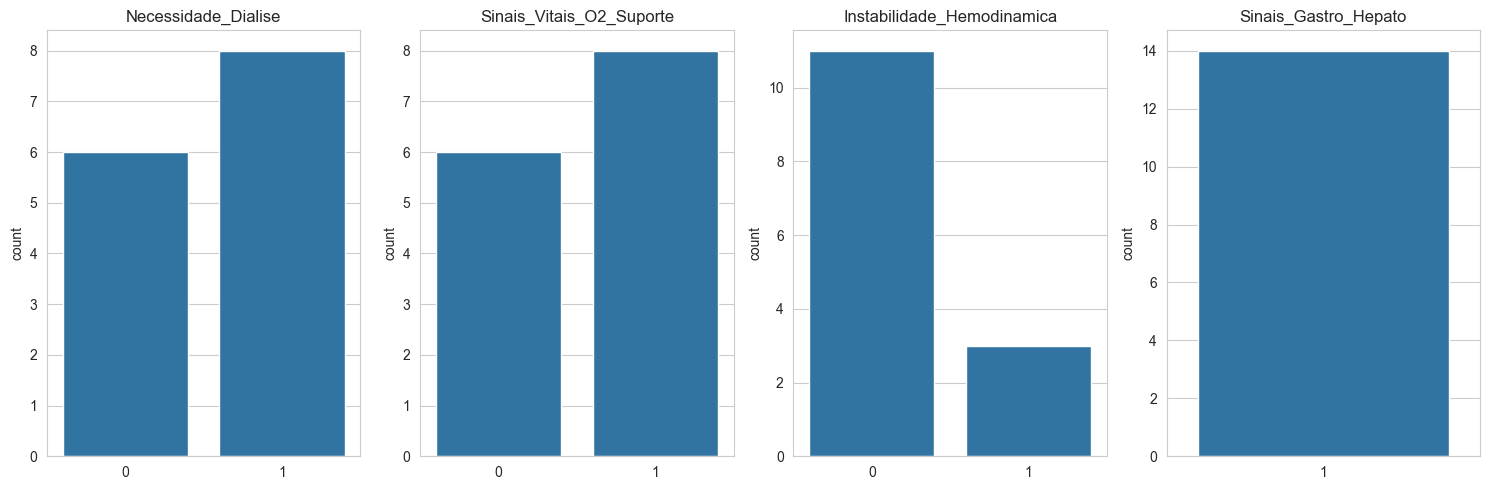

In [56]:
# Colunas binárias (Flags de risco)
flags = ['Necessidade_Dialise', 'Sinais_Vitais_O2_Suporte', 
         'Instabilidade_Hemodinamica', 'Sinais_Gastro_Hepato']

# Plotar a frequência de cada flag
plt.figure(figsize=(15, 5))
for i, col in enumerate(flags):
    plt.subplot(1, 4, i+1)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xlabel("")
plt.tight_layout()
plt.show()

# 6. Análise de Falhas Totais de Extração ⚠️

Identifiquei arquivos onde meu parser **não conseguiu encontrar o bloco de texto clínico**. Isolei esses casos para entender se eram problemas de layout (ex: prontuários com formatação diferente) e para documentar as limitações atuais da ferramenta de extração.

In [57]:
falhas_totais = df[df['Diagnostico_Texto_Livre'] == "TEXTO NÃO ENCONTRADO"]

print(f"Total de arquivos onde o Regex não achou o bloco clínico: {len(falhas_totais)}")
print("\nArquivos com falha de layout:")
print(falhas_totais['Nome_Arquivo'].tolist())

Total de arquivos onde o Regex não achou o bloco clínico: 0

Arquivos com falha de layout:
[]


# 7. Auditoria de Idades Suspeitas (Correção de OCR) 🕵️‍♂️

Como estamos tratando de uma enfermaria adulta, idades menores que 18 anos são, na maioria, erros de leitura do OCR (ex: o número `71` sendo lido como `1`).

**Minha estratégia:** Filtrei esses casos e imprimi o texto bruto original. Isso me permitiu fazer uma "engenharia reversa" para descobrir quais caracteres estranhos estavam quebrando a leitura da idade e corrigir o limpador de texto posteriormente.

In [58]:
# Carregar dados
df = pd.read_csv('../data/processed/dataset_espelhos.csv')

# Filtrar casos com idade suspeita (menor que 18 anos) para auditoria
suspeitos = df[df['Idade'] < 18]

print(f"Total de casos suspeitos (Idade < 18): {len(suspeitos)}")

# Vamos olhar o texto bruto desses casos para descobrir o caractere "ladrão" de idade
for index, row in suspeitos.iterrows():
    print(f"\n--- Arquivo: {row['Nome_Arquivo']} | Idade Extraída: {row['Idade']} ---")
    # Mostra os primeiros 100 caracteres do diagnóstico para vermos o padrão da idade
    print(f"Texto Inicial: {row['Diagnostico_Texto_Livre'][:150]}...")

Total de casos suspeitos (Idade < 18): 0
